# **1. Title**
**Utility-Based Autonomous Vacuum Cleaning Agent for a Campus Environment**

# **2. Aim**
**The aim of this experiment is to create a vacuum cleaning agent that can move around different areas of a campus, decide which place should be cleaned, clean the selected place, and manage its battery while working.**

**The agent should not be given every movement manually. It should make its own decisions using the information available about each location.**

# **3. Experiment Objectives**

The main objectives of this experiment are:

1. To create a simple campus environment using Python.
2. To represent different campus locations and the connections between them.
3. To give each location a different amount of dirt and priority.
4. To make the vacuum agent select a cleaning location by itself.
5. To use Breadth First Search to find a route between two locations.
6. To keep track of the agent's battery level.
7. To reduce the battery when the agent moves or cleans.
8. To maintain information about the places already visited.
9. To handle unsafe or unavailable locations when required.
10. To run the agent for multiple cycles and display its final performance.


# **4. Experiment Outcomes**
After executing the program, the vacuum agent was able to perform the main tasks for which it was designed.

The agent started from the Dock and checked the available locations. It selected a location based on its utility instead of simply following a fixed order.

It was also able to find a path from its current location to another location using Breadth First Search.

During movement, the battery value was reduced. The battery was also reduced when the agent cleaned a room. If the battery became low, the agent could return to the Dock and charge again.

The program also kept track of the number of rooms cleaned, total dirt removed, distance travelled and locations visited.

For example, if one room has more dirt and another room has less dirt, the first room may be preferred. However, distance and priority are also considered, so the dirtiest room is not automatically selected every time.

# **5. Conceptual Details**
### **5.1 Basic Idea of the Agent**

The main idea of this experiment is to make the vacuum behave like a small intelligent robot.

Normally, we could write a program such as:

Go to Room 1
Clean Room 1
Go to Room 2
Clean Room 2
Go to Room 3

But that would be a fixed program.

In this experiment, the agent decides what to do based on the current condition of the campus.

The program stores information about each location and uses that information while making decisions.

### **5.2 Campus Representation**

The campus is represented using different locations such as:

* Dock
* Corridor
* Library
* Classroom
* Cafeteria
* Auditorium
* Laboratory

Each location has information about its condition.

The information is stored in the following form:

**[dirt, priority, occupied, restricted, hazard]**

For example, a location may have a high dirt value and a high priority. Another location may have less dirt but may be more important.

The actual values are given in the Python program.

### **5.3 Agent State**

The program also stores the current condition of the vacuum agent.

It keeps information such as:

Current location
Battery
Number of rooms cleaned
Total dirt removed
Distance travelled
Visited locations
Postponed locations

This information is stored inside the agent dictionary in the program.

For example, when the agent moves from one place to another, its current location changes and its battery decreases.

### **5.4 Movement Between Locations**

The campus locations are connected like a graph.

The **paths** dictionary tells the program which locations can be reached from each location.

For example:

Dock --> Corridor
Corridor --> Library
Corridor --> Classroom
Corridor --> Cafeteria

and so on.

This allows the program to treat the campus as a small network instead of storing a separate movement instruction for every possible situation.

### **5.5 Breadth First Search**

The program uses **Breadth First Search (BFS)** to find a route.

BFS starts from the current location and checks the connected locations one level at a time.

For example, suppose the agent is at the Dock and wants to reach the Cafeteria.

The program can find a path like:

Dock --> Corridor --> Cafeteria

The **find_route()** function creates a queue and stores possible paths in it. Once the destination is found, the path is returned.

This is useful because the agent does not need to be told the complete route manually.

### **5.6 Utility-Based Decision**

One of the main parts of the experiment is choosing which place to clean.

The program calculates a score for each possible location.

The basic formula used in the code is:

Score = Dirt + (Priority * 20) - (Distance * 5)

The exact numbers are part of the program design.

The meaning is simple:

* More dirt increases the score.
* Higher priority increases the score.
* More travelling distance decreases the score.

The location with the best score is selected as the next task.

This is why the agent is called **utility-based**. It compares different choices instead of blindly selecting the first available room.

The calculation is performed inside choose_task().

### **5.7 Cleaning**

When the agent reaches a location that needs cleaning, the **clean()** function is called.

First, the program checks whether the location is safe and whether there is enough dirt to clean.

Then it calculates the battery cost of cleaning.

The code uses:

Cleaning cost = maximum of 5 and dirt/10

After cleaning:

* the dirt value becomes zero,
* battery decreases,
* cleaned-room count increases,
* total removed dirt increases.

This can be seen directly in the clean() function.

For example, if a room contains a certain amount of dirt, the program removes all of that dirt when cleaning is completed. It does not clean only a small portion.

### **5.8 Battery Management**

Battery is another important part of the experiment.

The agent starts with a full battery.

Every movement consumes some battery. The program decreases the battery by a fixed amount for each movement step.

Cleaning also consumes battery.

Before continuing with another task, the program checks whether the battery is low enough to require returning to the Dock.

The **low_battery()** function also considers the distance needed to return to the Dock.

This is better than checking only one fixed battery value because the agent's location also matters.

For example, having a moderate amount of battery may be enough when the agent is close to the Dock, but the same amount may not be enough if it is far away.

### **5.9 Safety Checking**

The program contains a safe() function.

It checks three conditions:

* whether the location is occupied,
* whether it is restricted,
* whether it has a hazard.

If any of these conditions is true, the location is not treated as a normal cleaning location.

The current input values can be changed to test these conditions.

For example, if the hazard value of a room is changed from 0 to 1, the program can identify that room as hazardous.

This makes the program easier to extend for different test cases.

### **5.10 Perceive, Decide and Act**

The program works in a simple cycle:

Perceive --> Decide --> Act

First, it looks at the current state.

Then, it decides what should happen.

Finally, it performs that action.

The decide() function chooses actions such as:

CHARGE
HAZARD
SKIP
WAIT
CLEAN
IDLE

or it can return the name of another location that should be visited.

The act() function then performs the selected action.

# **6. Algorithm / Flowchart Details**
### **6.1 Main Algorithm**

**Step 1**: Start the program.

**Step 2**: Create the campus environment and assign each location its dirt and priority values.

**Step 3**: Define the connections between campus locations.

**Step 4**: Initialize the agent at the Dock with 100% battery.

**Step 5**: Start the first decision cycle.

**Step 6**: Record the current location in the agent's memory.

**Step 7**: Check the current battery condition.

**Step 8**: If the battery is too low, select CHARGE and return to the Dock.

**Step 9**: Otherwise, check the current location for safety restrictions.

**Step 10**: If the current location requires cleaning, calculate the cleaning cost and clean it.

**Step 11**: If cleaning is not required at the current location, calculate utility scores for possible destinations.

**Step 12**: Select the location having the highest utility score.

**Step 13**: Use Breadth First Search to calculate a route to the selected location.

**Step 14**: Move along the calculated route and decrease the battery after every movement.

**Step 15**: Repeat the decision process until 15 cycles have been completed.

**Step 16**: Print the final performance report.

**Step 17**: Stop the program.

### **6.2 Task Selection**
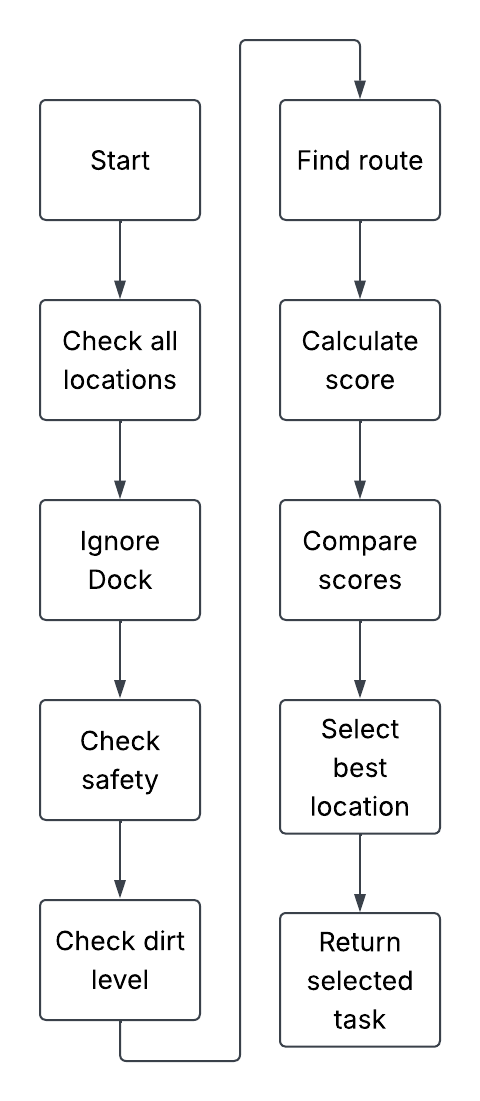

### **6.3 BFS Algorithm**
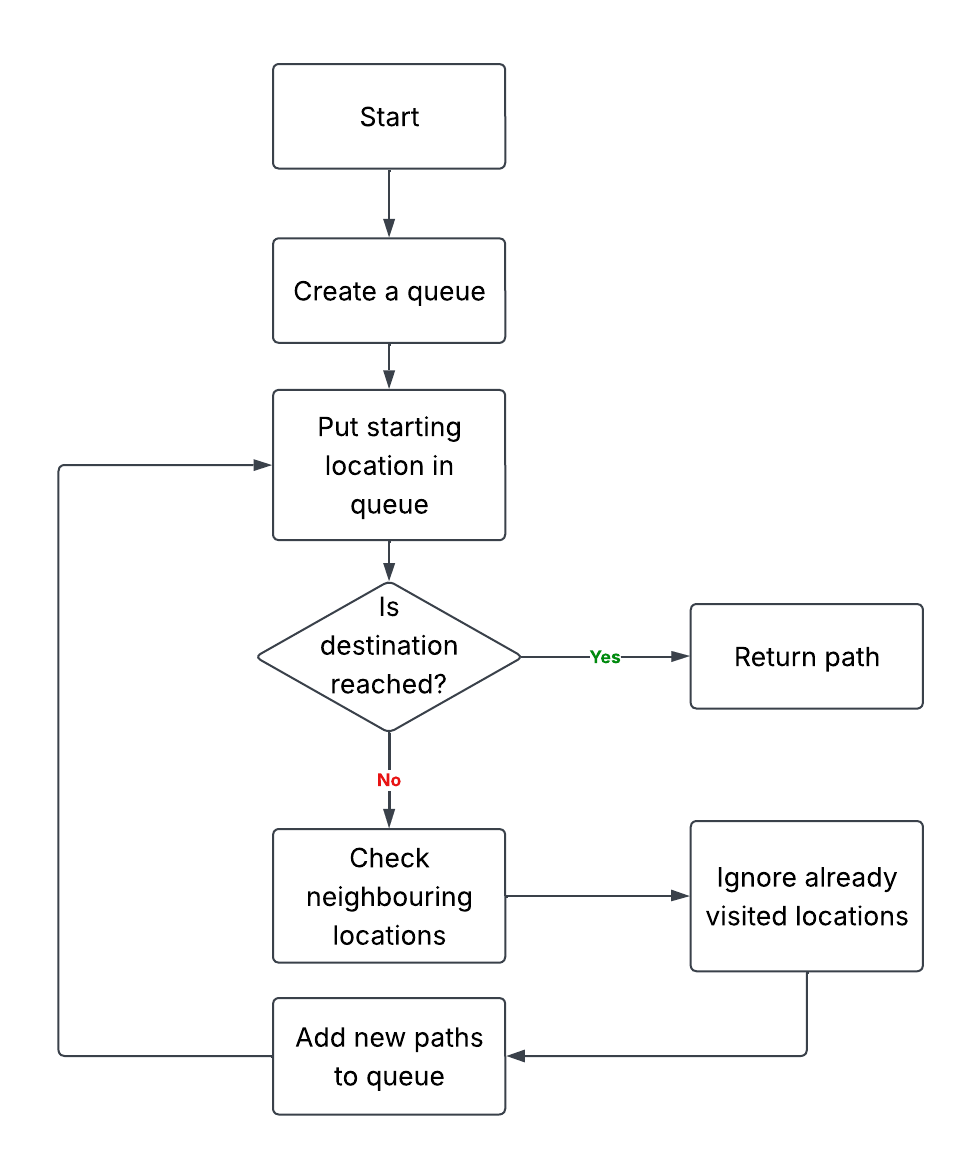

### **6.4 FLOWCHART**
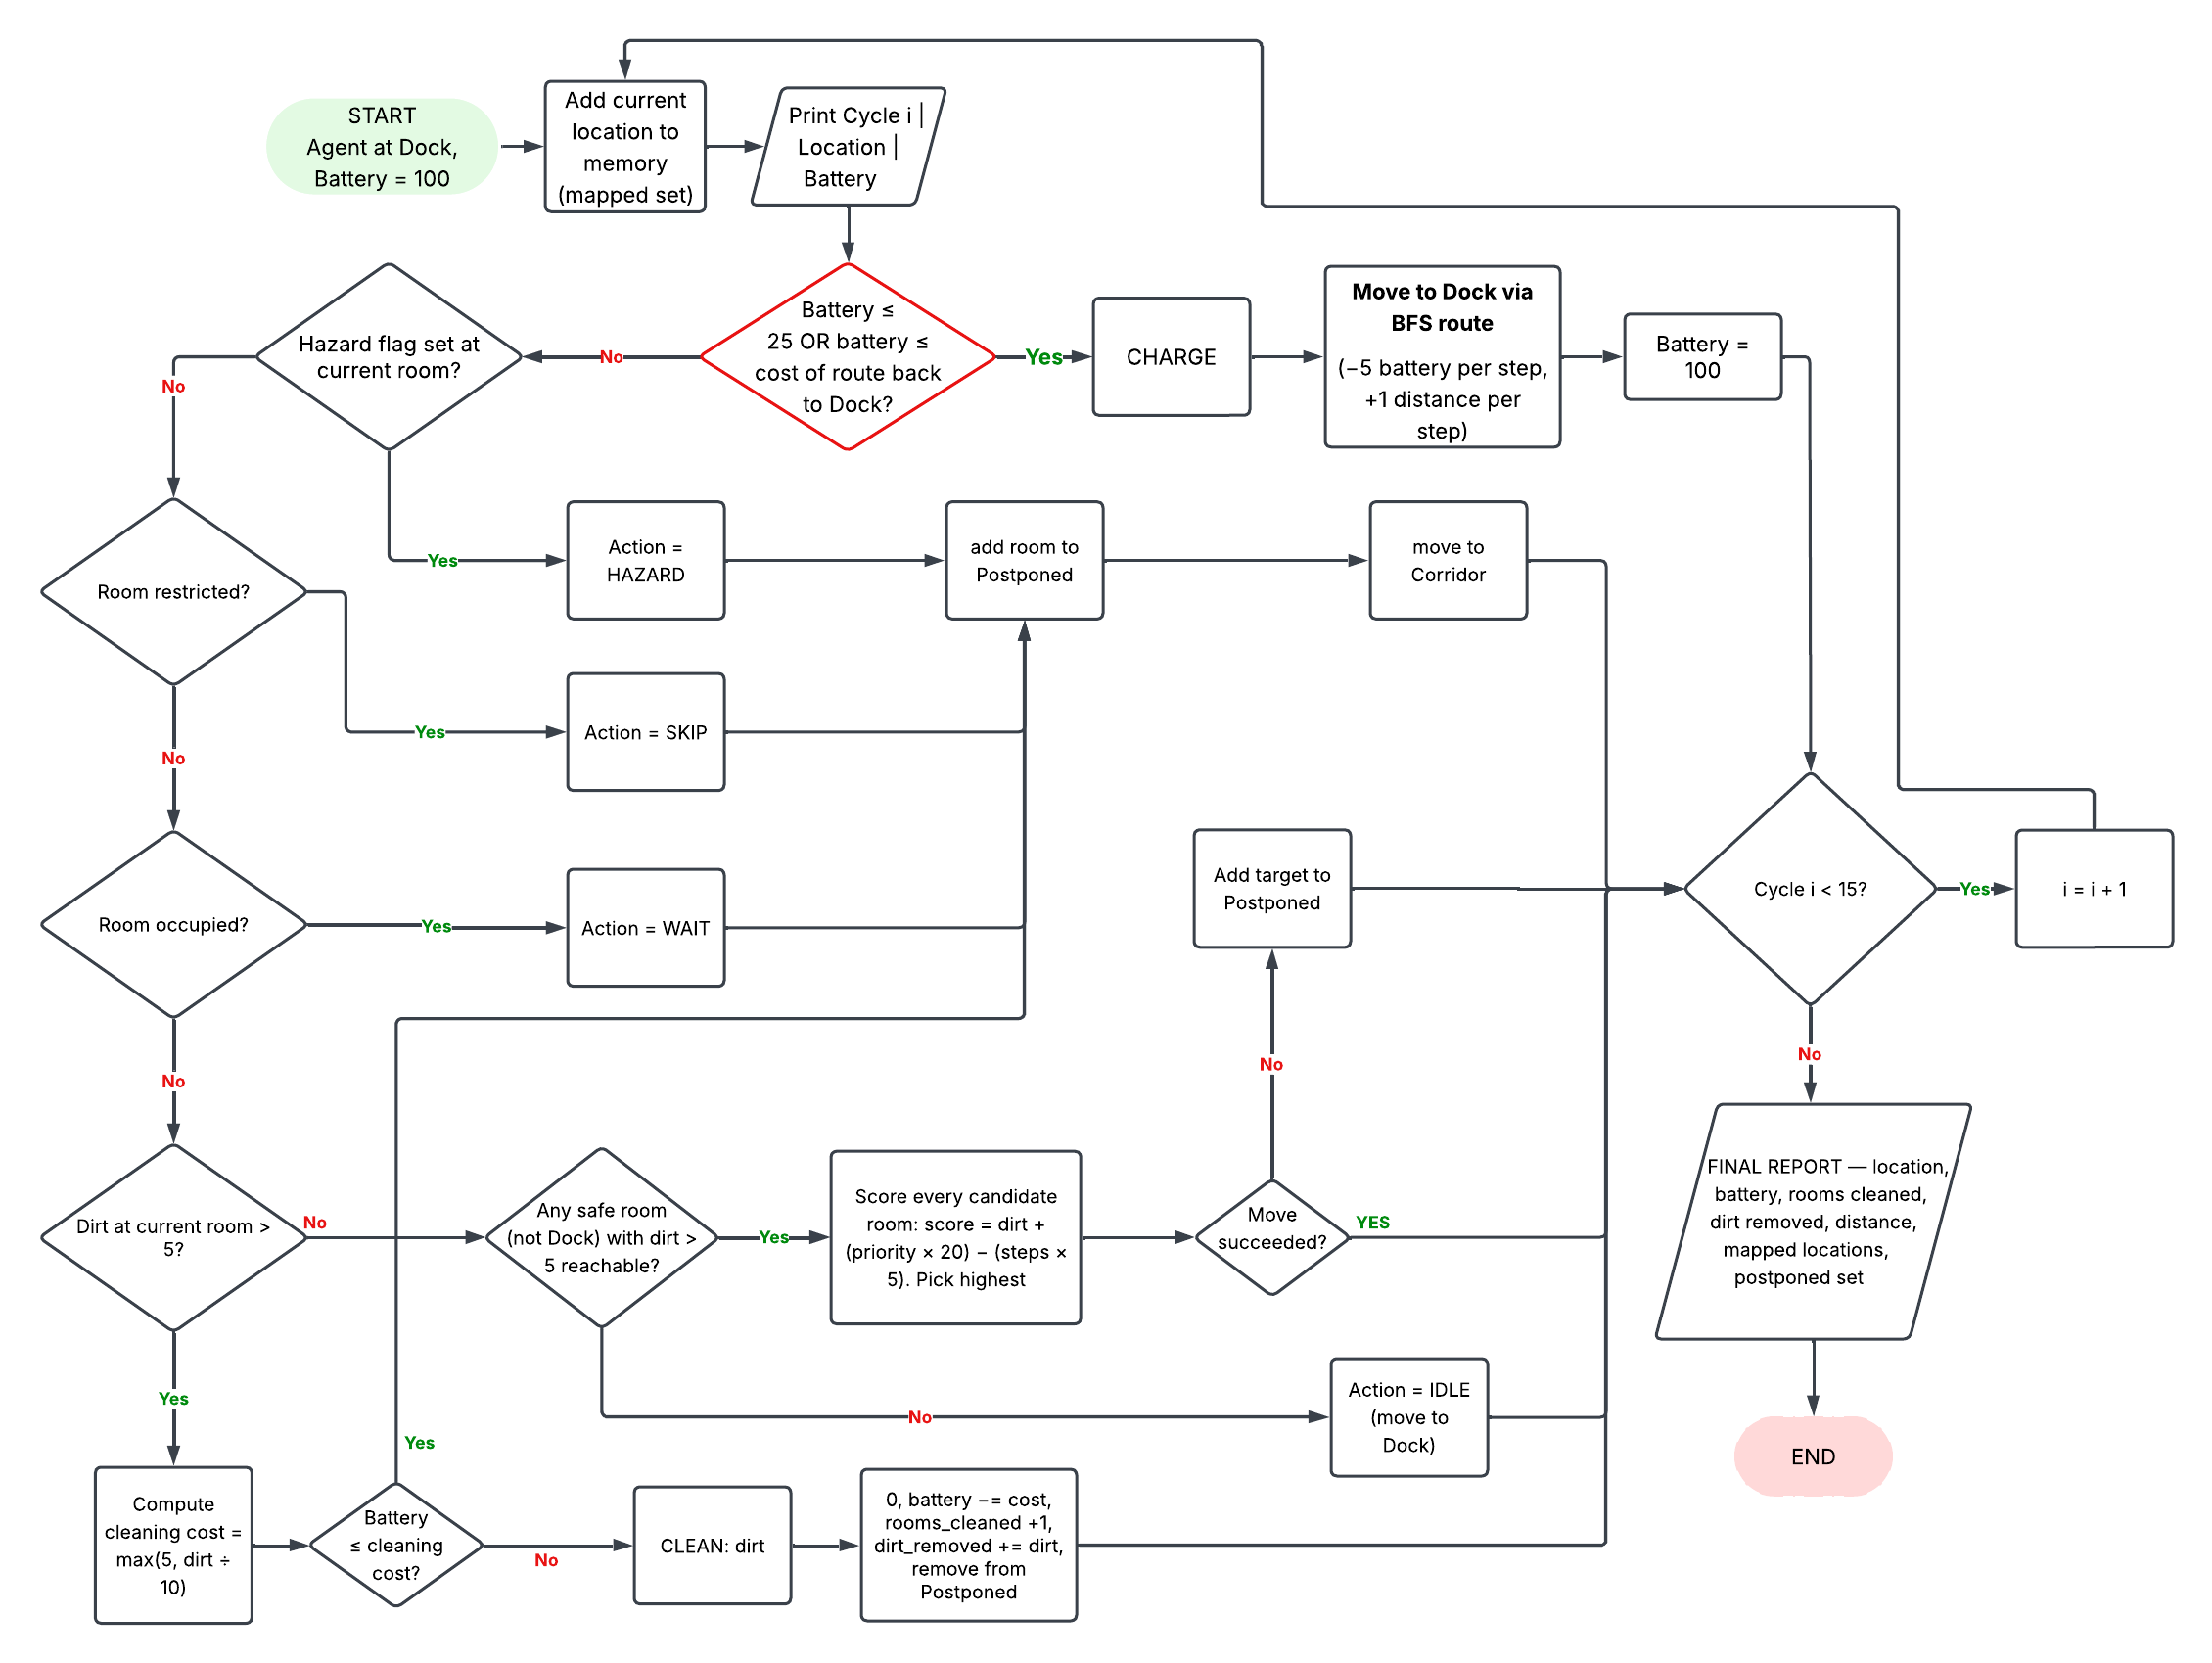

# **7. Code (Implementation)**
The uploaded implementation follows this same structure: campus initialization, graph-based movement, BFS routing, safety checking, utility-based task selection, cleaning, battery handling.

In [ ]:
from collections import deque

# Campus: dirt, priority, occupied, restricted, hazard
campus = {
    "Dock":        [0, 0, 0, 0, 0],
    "Corridor":    [55, 2, 0, 0, 0],
    "Library":     [80, 1, 0, 0, 0],
    "Classroom":   [55, 3, 0, 0, 0],
    "Cafeteria":   [155, 5, 0, 0, 0],
    "Auditorium":  [25, 2, 0, 0, 0],
    "Laboratory":  [45, 3, 0, 0, 0],
}

paths = {
    "Dock": ["Corridor"],
    "Corridor": ["Dock","Library","Classroom","Cafeteria","Auditorium","Laboratory",],
    "Library": ["Corridor"],
    "Classroom": ["Corridor"],
    "Cafeteria": ["Corridor"],
    "Auditorium": ["Corridor"],
    "Laboratory": ["Corridor"],
}
blocked = set()

agent = {
    "place": "Dock",
    "battery": 100,
    "cleaned": 0,
    "removed": 0,
    "distance": 0,
    "memory": set(),
    "postponed": set(),
}

def find_route(start, goal):
    q = deque([[start]])
    seen = {start}

    while q:
        path = q.popleft()

        if path[-1] == goal:
            return path

        for nxt in paths[path[-1]]:
            if nxt not in seen and nxt not in blocked:
                seen.add(nxt)
                q.append(path + [nxt])

    return None


def move(goal):
    path = find_route(agent["place"], goal)

    if not path:
        print("No route to", goal)
        return False

    print("Route:", " -> ".join(path))

    for place in path[1:]:
        if agent["battery"] < 5:
            print("Battery too low to move.")
            return False

        agent["place"] = place
        agent["battery"] -= 5
        agent["distance"] += 1
        agent["memory"].add(place)

    return True


def safe(place):
    room = campus[place]

    if room[2]:
        print(place, "is occupied.")
    elif room[3]:
        print(place, "is restricted.")
    elif room[4]:
        print(place, "has a hazard.")
    else:
        return True

    agent["postponed"].add(place)
    return False


def charge():
    if agent["place"] == "Dock":
        agent["battery"] = 100
        print("Battery charged to 100%")


def low_battery():
    path = find_route(agent["place"], "Dock")
    return agent["battery"] <= 25 or (
        path and agent["battery"] <= (len(path) - 1) * 5 + 5
    )


def choose_task():
    best = None
    best_score = -1

    for place, room in campus.items():
        if place == "Dock" or not safe(place) or room[0] <= 5:
            continue

        path = find_route(agent["place"], place)
        if path:
            score = room[0] + room[1] * 20 - (len(path) - 1) * 5

            if score > best_score:
                best, best_score = place, score

    return best


def clean():
    place = agent["place"]
    room = campus[place]

    if not safe(place) or room[0] <= 5:
        return

    cost = max(5, room[0] // 10)

    if agent["battery"] <= cost:
        print("Cleaning postponed: battery too low.")
        agent["postponed"].add(place)
        return

    dirt = room[0]
    room[0] = 0
    agent["battery"] -= cost
    agent["cleaned"] += 1
    agent["removed"] += dirt
    agent["postponed"].discard(place)

    print("Cleaned:", place, "| Dirt removed:", dirt)


def decide():
    room = campus[agent["place"]]

    if low_battery():
        return "CHARGE"

    if room[4]:
        return "HAZARD"

    if room[3]:
        return "SKIP"

    if room[2]:
        return "WAIT"

    if room[0] > 5:
        return "CLEAN"

    return choose_task() or "IDLE"


def act(action):
    place = agent["place"]

    if action == "CHARGE":
        print("Returning to charging station.")
        if place != "Dock" and not move("Dock"):
            return
        charge()

    elif action == "CLEAN":
        clean()

    elif action in ("HAZARD", "SKIP", "WAIT"):
        print("Action:", action)
        if place != "Corridor":
            move("Corridor")

    elif action == "IDLE":
        print("No available cleaning task.")
        if place != "Dock":
            move("Dock")

    else:
        print("Moving to:", action)
        if not move(action):
            agent["postponed"].add(action)


def run(cycles):
    for i in range(1, cycles + 1):
        agent["memory"].add(agent["place"])

        print(
            "\nCycle", i, "| Location:", agent["place"], "| Battery:", agent["battery"]
        )

        action = decide()
        print("Decision:", action)
        act(action)


def report():
    print("\n--- FINAL REPORT ---")
    print("Location:", agent["place"])
    print("Battery:", agent["battery"])
    print("Rooms cleaned:", agent["cleaned"])
    print("Dirt removed:", agent["removed"])
    print("Distance:", agent["distance"])
    print("Mapped locations:", len(agent["memory"]))
    print("Postponed:", agent["postponed"])


run(15)
report()


Cycle 1 | Location: Dock | Battery: 100
Decision: Cafeteria
Moving to: Cafeteria
Route: Dock -> Corridor -> Cafeteria

Cycle 2 | Location: Cafeteria | Battery: 90
Decision: CLEAN
Cleaned: Cafeteria | Dirt removed: 155

Cycle 3 | Location: Cafeteria | Battery: 75
Decision: Classroom
Moving to: Classroom
Route: Cafeteria -> Corridor -> Classroom

Cycle 4 | Location: Classroom | Battery: 65
Decision: CLEAN
Cleaned: Classroom | Dirt removed: 55

Cycle 5 | Location: Classroom | Battery: 60
Decision: Laboratory
Moving to: Laboratory
Route: Classroom -> Corridor -> Laboratory

Cycle 6 | Location: Laboratory | Battery: 50
Decision: CLEAN
Cleaned: Laboratory | Dirt removed: 45

Cycle 7 | Location: Laboratory | Battery: 45
Decision: Corridor
Moving to: Corridor
Route: Laboratory -> Corridor

Cycle 8 | Location: Corridor | Battery: 40
Decision: CLEAN
Cleaned: Corridor | Dirt removed: 55

Cycle 9 | Location: Corridor | Battery: 35
Decision: Library
Moving to: Library
Route: Corridor -> Library

C

# **8. Result Analysis**
### **8.1 What We Observe**

When the program starts, the agent is placed at the Dock.

It does not immediately clean the Dock because there is no dirt there.

It then checks the other locations and calculates their utility scores.

The selected location depends on three main things:

1. Amount of dirt
2. Priority of location
3. Distance from current position

The agent then finds a route using BFS and moves to that location.

### **8.2 Example of Utility Calculation**

Suppose a location has:

Dirt = 60
Priority = 3
Distance = 2 steps

Then its score would be:

Score = 60 + (3 * 20) - (2 * 5)

Score = 60 + 60 - 10

Score = 110

This is only an example to explain the calculation. The actual values used by the experiment are taken from the Python program.

The important point is that the agent compares the available locations before choosing one.

### **8.3 Example of Movement**

Suppose the agent is at the Dock and the selected destination is connected through the Corridor.

The route can be:

Dock --> Corridor --> Selected Location

The move() function processes each location in the path and decreases the battery for every movement. It also increases the distance counter and stores the visited location in memory.

### **8.4 Example of Cleaning**

Suppose a selected room has a dirt value of 80.

The program calculates the cleaning cost using its formula and then:

stores the current dirt value,
changes the dirt value to zero,
reduces the battery,
increases the number of cleaned rooms,
adds the removed dirt to the total.

Therefore, after successful cleaning, that room is considered clean by the program.

### **8.5 Final Report**

At the end of the experiment, the program prints:

FINAL REPORT

1. Location
2. Battery
3. Rooms cleaned
4. Dirt removed
5. Distance
6. Mapped locations
7. Postponed tasks

These values help us understand how the agent performed during the experiment. The report() function is responsible for displaying them.

Instead of only looking at whether the program runs successfully, these values allow us to check the agent's performance.

For example:

* **Rooms cleaned** tells us how many cleaning tasks were completed.
* **Dirt removed** tells us how much cleaning was actually done.
* **Distance** tells us how much the agent travelled.
* **Battery** shows the remaining energy.
* **Mapped locations** shows how many locations the agent has recorded.
* **Postponed tasks** shows whether some tasks were delayed.

### **8.6 Overall Observation**

The experiment shows that the vacuum agent can make its own decisions using the information stored in the environment.

It does not simply move randomly.

It first checks the available options, calculates their usefulness, selects a task, finds a route and then performs the required action.

The battery is also considered during the process. This makes the experiment closer to the behaviour expected from an autonomous cleaning robot.

The main purpose of this experiment is therefore not only to clean rooms. It is to demonstrate how an **AI agent can observe a situation, compare possible actions, choose one and perform it while keeping track of its own state.**



# **9. Conclusion**

In this experiment, a utility-based vacuum cleaning agent was created using Python.

The campus was represented as a group of connected locations. Each location had its own dirt and priority information. The agent used this information to decide where it should go next.

Breadth First Search was used for finding routes between locations. This made it possible for the agent to move through the campus without manually specifying every route.

The utility function helped the agent compare different cleaning options. It considered the dirt present, the priority of the location and the distance that had to be travelled.

The agent also kept track of its battery. Movement and cleaning reduced the battery, and the program included a charging mechanism for returning to the Dock when necessary.

The experiment also showed how the agent can maintain its own information, such as visited locations, cleaned rooms, removed dirt and travelled distance.

Overall, this experiment helped demonstrate the basic working of an intelligent agent in a simple and understandable way. **The main idea was to make the vacuum decide what to do instead of simply following a fixed list of instructions.**

The program can be improved further by changing the campus conditions during execution, adding more locations, introducing changing obstacles and allowing the agent to reconsider previously postponed tasks.